# **PUC-Rio | Departamento de Engenharia Industrial**
# **ENG 4560: Projeto Integrado VI - Distribuição Física**

---

## **Aula 2 — Preparação, tratamento e estruturação da base de dados**

**Prof. Marcello Congro (marcellocongro@puc-rio.br)**

---

## Objetivos da Aula

Ao final desta aula, você será capaz de:

1. Transformar uma base operacional real em uma estrutura de dados adequada para modelagem do **CVRP**;
2. Construir as principais entradas do modelo matemático:
   - conjunto de nós (depósito + clientes),
   - vetor de demanda,
   - matriz de distâncias,
   - matriz de custos,
   - matriz de tempos;
3. Gerar **instâncias** com diferentes tamanhos (C1–C4) para analisar **escalabilidade computacional**;
4. Exportar datasets completos e consistentes para a **Aula 3**, onde implementaremos a solução exata via **Programação Linear Inteira (PLI)**.

---

## Definição: o que é uma instância?

Nesta disciplina, uma **instância** do CVRP será representada por:

$$
\mathcal{I} = (N, D, q, \mathcal{K}, Q, g, v, s, H)
$$

onde:

- $N = \{0,1,\dots,n\}$ é o conjunto de nós (0 = depósito, demais = clientes);
- $D_{ij}$ é a matriz de distâncias entre nós $i$ e $j$;
- $q_i$ é a demanda do cliente $i$ (nesta aula: $q_i$ = peso em kg);
- $\mathcal{K}$ é o conjunto de tipos de veículos (Fiorino, VUC);
- $Q_k$ é a capacidade do veículo do tipo $k$;
- $g$ é o custo variável por km;
- $v$ é a velocidade média operacional;
- $s$ é o tempo de atendimento por cliente;
- $H$ é a jornada máxima.

Ao selecionar um subconjunto de clientes, criamos uma nova instância com menor cardinalidade de $N$.  
Essa estratégia permite comparar esforço computacional e qualidade de solução à medida que o problema cresce.

---

## Por que precisamos estruturar nossos dados?

Na Aula 3, resolveremos o seguinte problema (forma conceitual):

$$
\min \sum_{i \in N} \sum_{j \in N} c_{ij} \, x_{ij}
$$

onde:

- $x_{ij}$ indica se o arco $(i,j)$ é percorrido por algum veículo;
- $c_{ij}$ é o custo do arco, calculado nesta aula como:

$$
c_{ij} = g \cdot D_{ij}
$$

Logo, a principal missão da Aula 2 é transformar a planilha operacional em:

- $D_{ij}$ (matriz de distâncias),
- $c_{ij}$ (matriz de custos),
- $q_i$ (vetor de demandas),
- $t_{ij}$ (matriz de tempos),

de forma estruturada, reprodutível e consistente.

---

## Observação importante sobre distância

Nesta aula, calcularemos distâncias a partir de coordenadas determinísticas derivadas do CEP.

Essa abordagem:

- não representa a distância viária real;
- é uma aproximação geométrica;
- garante reprodutibilidade e controle total do experimento computacional.

Nosso objetivo não é modelar o trânsito real, mas estruturar corretamente os parâmetros do modelo matemático.

Em aplicações reais, utilizaríamos distâncias viárias obtidas via APIs e serviços como:

- OSRM,
- HERE,
- Google Maps Platform.

Entretanto, para os fins didáticos desta disciplina, a aproximação geométrica é metodologicamente adequada e suficiente.

###**Configuração logística do problema (parâmetros)**

Nesta célula definimos os parâmetros operacionais que serão usados
na construção das entradas do modelo:

- Depósito (CEP do CD)
- Frota (tipos, capacidades, custos fixos)
- Custo variável por km (g)
- Velocidade média (v)
- Tempo de atendimento por cliente (s)
- Jornada máxima (H)

Esses parâmetros aparecem explicitamente nas equações do problema.

---

In [ ]:
import pandas as pd
import numpy as np
import math
import itertools
import random
from pathlib import Path

# Depósito (origem e destino de todas as rotas)
DEPOT_CEP = "25251560"

# Veículos
VEHICLES = {
    "Fiorino": {"Q_kg": 650,  "custo_fixo_diario": 250},
    "VUC":     {"Q_kg": 3000, "custo_fixo_diario": 550},
}

# Custos e tempos
g = 1.50                  # custo variável (R$/km)
v_kmh = 40.0              # velocidade média (km/h)
s_min = 15.0              # tempo de atendimento (min)
H_horas = 8.0             # jornada máxima (h)

# Conversões úteis para a modelagem
s_horas = s_min / 60.0    # s em horas
H_min = H_horas * 60.0    # jornada em minutos (às vezes útil)

## 1. Leitura da base operacional

A planilha contém dados reais para um dia único de operação.

Cada linha representa uma agregação (por CEP) ou um registro que pode repetir CEP.

Do ponto de vista logístico, queremos construir o conjunto de clientes $N$ onde cada cliente aparece **uma única vez**.
Se um CEP aparece múltiplas vezes, isso significa múltiplos pedidos para o mesmo ponto, e precisamos **agregar**.


In [ ]:
from google.colab import files

print("Faça upload do arquivo xlsx")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

# Lendo o arquivo
df_raw = pd.read_excel(file_name)

# Exibindo as primeiras linhas para inspeção visual
display(df_raw.head())
print(f"Dimensões da base bruta: {df_raw.shape}")
df_raw.info()

Faça upload do arquivo xlsx


Saving Base de Dados.xlsx to Base de Dados (5).xlsx


,DataEmissao,CEP Entrega,Qtd volumes,Peso real (kg),Valor da mercadoria (R$)
0,2025-06-03,26383060,5,20.424,724.23
1,2025-06-03,26383080,3,9.336,797.38
2,2025-06-03,26383060,1,1.180,24.46
3,2025-06-03,26325282,1,3.174,595.71
4,2025-06-03,26311110,14,120.802,3600.79


Dimensões da base bruta: (1021, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1021 entries, 0 to 1020
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   DataEmissao               1021 non-null   datetime64[ns]
 1   CEP Entrega               1021 non-null   int64         
 2   Qtd volumes               1021 non-null   int64         
 3   Peso real (kg)            1021 non-null   float64       
 4   Valor da mercadoria (R$)  1021 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 40.0 KB


## 2. Padronização e agregação por cliente (CEP)

### Por que agregamos?
No CVRP, cada cliente $i$ deve ser um nó único.  
Se o mesmo CEP aparece várias vezes, o veículo não “visita” várias vezes a mesma localização; o correto é somar as demandas e atributos.

Matematicamente, para um CEP que aparece em várias linhas:

$$q_i = \sum_{\ell \in \text{linhas do CEP}} q_\ell$$



Aqui definiremos:
* **$q_i$** = peso total (kg) do cliente $i$
* **Volumes e valor** serão atributos adicionais para análise

In [ ]:
########################################################################
# Este bloco:
# 1) identifica a coluna de CEP,
# 2) identifica automaticamente colunas de volume/peso/valor,
# 3) padroniza nomes para: volumes, peso_kg, valor_rs
# 4) agrega por CEP (um nó por cliente)

# Saída:
# df com colunas: CEP, volumes, peso_kg, valor_rs
########################################################################

df = df_raw.copy()

# Identifica coluna do CEP
col_cep = None
for c in df.columns:
    c_low = str(c).lower()
    if "rótulos" in c_low or "rotulos" in c_low or c_low.strip() == "cep" or "cep" in c_low:
        col_cep = c
        break
if col_cep is None:
    raise ValueError("Não encontrei a coluna de CEP. Verifique o Excel.")

df = df.rename(columns={col_cep: "CEP"})

def find_col_by_keywords(columns, keywords):
    for c in columns:
        name = str(c).lower()
        if all(k in name for k in keywords):
            return c
    return None

col_vol = find_col_by_keywords(df.columns, ["volume"]) or find_col_by_keywords(df.columns, ["volum"])
col_peso = find_col_by_keywords(df.columns, ["peso"]) or find_col_by_keywords(df.columns, ["kg"])
col_val  = find_col_by_keywords(df.columns, ["valor"]) or find_col_by_keywords(df.columns, ["mercadoria"])

missing = []
if col_vol is None: missing.append("VOLUMES")
if col_peso is None: missing.append("PESO")
if col_val is None: missing.append("VALOR")

if missing:
    print("Colunas disponíveis no Excel:")
    for c in df.columns:
        print("-", c)
    raise ValueError(f"Não identifiquei as colunas: {missing}. Ajuste palavras-chave ou nomes no Excel.")

df = df.rename(columns={col_vol: "volumes", col_peso: "peso_kg", col_val: "valor_rs"})

# Padroniza CEP e filtra válidos
df["CEP"] = df["CEP"].astype(str).str.replace(r"\D", "", regex=True)
df = df[df["CEP"].str.len() == 8].copy()

# Numéricos
for col in ["volumes", "peso_kg", "valor_rs"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove inválidos
df = df.dropna(subset=["CEP", "volumes", "peso_kg", "valor_rs"])
df = df[(df["volumes"] >= 0) & (df["peso_kg"] >= 0) & (df["valor_rs"] >= 0)].copy()

# CEPs repetidos
rep = df["CEP"].value_counts()
rep = rep[rep > 1]
print(f"CEPs repetidos (mesmo cliente em múltiplas linhas): {len(rep)}")
if len(rep) > 0:
    display(rep.head(10))

#######################################################################
# PREENCHA O CÓDIGO INCOMPLETO ABAIXO:

# Agrega por cliente (um nó por CEP)
df = df.groupby("CEP", as_index=False).agg({
    "volumes":
    "peso_kg":
    "valor_rs":
})
#######################################################################
print("Base consolidada (um cliente por CEP):", df.shape)
df.head()

CEPs repetidos (mesmo cliente em múltiplas linhas): 243


,count
CEP,
22631002,10
22451540,9
25915000,6
22041012,6
26155070,6
22451350,6
22230060,6
23890001,6
25576011,6


Base consolidada (um cliente por CEP): (581, 4)


,CEP,volumes,peso_kg,valor_rs
0,20000001,24,120.003,5114.61
1,20080003,4,3.707,746.42
2,20080004,1,1.026,188.91
3,20211260,1,4.560,158.05
4,20211270,10,40.233,2278.68


## 3. Coordenadas e distâncias

Para calcular $D_{ij}$, precisamos de coordenadas $(lat_i, lon_i)$ para cada nó.

Nesta aula, usaremos um mapeamento determinístico do CEP para coordenadas dentro de uma “caixa” geográfica do RJ. Isso permite obter distâncias coerentes e reprodutíveis, sem depender de serviços externos.

---

### 3.1 Distância geográfica (Haversine)

Para calcular a distância entre dois pontos em uma esfera (como a Terra), usaremos a **fórmula de Haversine**:

$$D_{ij} = 2R \arcsin\left(\sqrt{\sin^2\left(\frac{\phi_i-\phi_j}{2}\right) + \cos(\phi_i)\cos(\phi_j)\sin^2\left(\frac{\lambda_i-\lambda_j}{2}\right)}\right)$$



**Onde:**
* $R \approx 6371$ km (raio médio da Terra)
* $\phi$ = latitude em radianos
* $\lambda$ = longitude em radianos

In [ ]:
##############################################################
# Saídas:
# df passa a ter lat, lon
# depot_lat, depot_lon
# função haversine() para calcular D_ij

# Bounding box RJ (aproximação)
LAT_MIN, LAT_MAX = -23.2, -22.3
LON_MIN, LON_MAX = -44.5, -42.8

def cep_to_latlon(cep: str):
    """
    Tradução logística:
    associa cada CEP a uma posição espacial coerente.
    Isso permite calcular D_ij, que entra no custo e no tempo.
    """
    cep_num = int(cep)
    u = (cep_num % 10000) / 10000.0
    v = ((cep_num // 10000) % 10000) / 10000.0
    lat = LAT_MIN + u * (LAT_MAX - LAT_MIN)
    lon = LON_MIN + v * (LON_MAX - LON_MIN)
    return lat, lon

def haversine(lat1, lon1, lat2, lon2):
    """
    D_ij (km) pela fórmula de Haversine.
    """
    R = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)

    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    return R * c

# Coordenadas dos clientes
df["lat"], df["lon"] = zip(*df["CEP"].apply(cep_to_latlon))

# Coordenadas do depósito
depot_lat, depot_lon = cep_to_latlon(DEPOT_CEP)
df.head()

,CEP,volumes,peso_kg,valor_rs,lat,lon
0,20000001,24,120.003,5114.61,-23.19991,-44.16000
1,20080003,4,3.707,746.42,-23.19973,-44.15864
2,20080004,1,1.026,188.91,-23.19964,-44.15864
3,20211260,1,4.560,158.05,-23.08660,-44.15643
4,20211270,10,40.233,2278.68,-23.08570,-44.15643


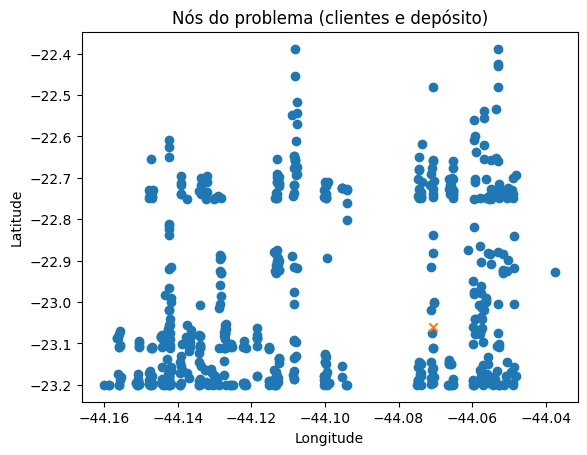

In [ ]:
# ============================================================
# Visualização geográfica dos nós
# ============================================================

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df["lon"], df["lat"])
plt.scatter([depot_lon], [depot_lat], marker="x")
plt.title("Nós do problema (clientes e depósito)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## 4. Construção das matrizes logísticas $D_{ij}$, $c_{ij}$ e $t_{ij}$

### 4.1 Matriz de distâncias

A distância entre cada par de nós $i$ e $j$ é representada por:

$$D_{ij} = \text{distância}(i,j)$$

### 4.2 Matriz de custo variável

Considerando um custo por quilômetro rodado $g$ (em R$/km), o custo de deslocamento entre os nós é:

$$c_{ij} = g \cdot D_{ij}$$

### 4.3 Matriz de tempo de deslocamento

Considerando uma velocidade média $v$ (em km/h), o tempo de viagem entre os nós é dado por:

$$t_{ij} = \frac{D_{ij}}{v}$$



---

O **tempo total de uma rota**, no nível conceitual, será a soma do tempo de deslocamento entre os nós visitados e o tempo de serviço em cada cliente:

$$\text{TempoRota} = \sum t_{ij}x_{ij} + \sum s \cdot y_i$$

**Onde:**
* $s$ = tempo fixo de atendimento (descarga/serviço) em cada parada.
* $y_i$ = variável indicadora que assume 1 se o cliente $i$ for visitado e 0 caso contrário.
* $x_{ij}$ = variável de decisão que assume 1 se o veículo percorre o arco entre $i$ e $j$.

In [ ]:
##############################################################
# Montamos uma lista de nós:
# nó 0 = depósito
# nós 1..n = clientes
# Depois calculamos:
# D_ij (km)
# C_ij (R$)
# T_ij (h)
##############################################################

coords = [(depot_lat, depot_lon)] + list(zip(df["lat"], df["lon"]))
n_nodes = len(coords)

# D_ij
D = np.zeros((n_nodes, n_nodes), dtype=float)
for i, j in itertools.product(range(n_nodes), range(n_nodes)):
    if i != j:
        D[i, j] = haversine(coords[i][0], coords[i][1], coords[j][0], coords[j][1])

#################################################
# PREENCHA O CÓDIGO INCOMPLETO ABAIXO:

# Matriz de custo
Cvar =

# Matriz de tempo
Tmov_h =
#################################################

print("Dimensões:", D.shape, Cvar.shape, Tmov_h.shape)
print("Exemplo D (km) [0:5,0:5]:\n", np.round(D[:5,:5], 2))

Dimensões: (582, 582) (582, 582) (582, 582)
Exemplo D (km) [0:5,0:5]:
 [[0.000e+00 1.808e+01 1.799e+01 1.798e+01 9.260e+00]
 [1.808e+01 0.000e+00 1.400e-01 1.400e-01 1.260e+01]
 [1.799e+01 1.400e-01 0.000e+00 1.000e-02 1.258e+01]
 [1.798e+01 1.400e-01 1.000e-02 0.000e+00 1.257e+01]
 [9.260e+00 1.260e+01 1.258e+01 1.257e+01 0.000e+00]]


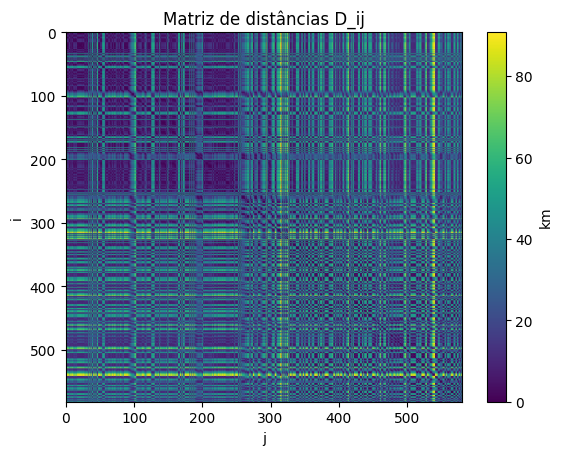

Distância máxima (km): 90.84171761612939


In [ ]:
# ============================================================
# Heatmap diagnóstico da matriz de distâncias
# ============================================================
plt.figure()
plt.imshow(D, aspect="auto")
plt.title("Matriz de distâncias D_ij")
plt.xlabel("j")
plt.ylabel("i")
plt.colorbar(label="km")
plt.show()

print("Distância máxima (km):", D.max())

# Note que:
# A diagonal é zero;
# A matriz é simétrica;
# A distância máxima parece coerente com uma operação dentro do RJ?

## 5. Vetor de demanda $q_i$ e tempos de atendimento

Nesta aula, definimos a demanda de cada nó baseada no peso total acumulado:

$$q_i = \text{peso\_kg}_i$$



### Capacidade por tipo de veículo ($Q$)
A capacidade máxima de carga varia conforme a frota disponível:
* **Fiorino:** $Q = 650$ kg  
* **VUC:** $Q = 3000$ kg  

### Tempo de atendimento ($s_i$)
Definimos um tempo fixo de parada em cada cliente para carga/descarga:

$$s_i = 0.25 \text{ h} \quad (15\ \text{min})$$

### Jornada máxima ($H$)
O limite de tempo operacional diário para cada veículo/rota:

$$H = 8 \text{ h}$$

---

In [ ]:
# q_i (kg) alimenta restrições de capacidade.
# s_i (h) alimenta restrições de tempo/jornada.

# q_i: depósito tem demanda 0, clientes têm demanda = peso_kg
q = np.concatenate(([0.0], df["peso_kg"].to_numpy(dtype=float)))

# s_i: depósito tem atendimento 0, clientes têm s_horas
s = np.concatenate(([0.0], np.full(len(df), s_horas, dtype=float)))

print("Demanda total (kg) no dia:", q.sum())
print("Tempo de atendimento total (h) se visitar todos:", s.sum())

Demanda total (kg) no dia: 25324.009
Tempo de atendimento total (h) se visitar todos: 145.25


In [ ]:
# ============================================================
# Validação adicional: inviabilidade estrutural da instância
# ============================================================

Q_max = max(v["Q_kg"] for v in VEHICLES.values())

clientes_inviaveis = np.where(q > Q_max)[0]
clientes_inviaveis = [i for i in clientes_inviaveis if i != 0]

if clientes_inviaveis:
    print("\n🚨 Clientes inviáveis detectados:\n")

    for idx in clientes_inviaveis:
        cep = df.iloc[idx - 1]["CEP"]   # porque 0 é depósito
        peso = q[idx]
        excesso = peso - Q_max

        print(f"Cliente global {idx}")
        print(f"CEP: {cep}")
        print(f"Demanda (kg): {peso:.2f}")
        print(f"Capacidade máxima disponível (kg): {Q_max}")
        print(f"Excesso (kg): {excesso:.2f}")
        print("-"*40)

    raise ValueError("Instância inviável: existe cliente com demanda > capacidade máxima.")
else:
    print("✔️ Nenhum cliente excede a capacidade máxima da frota.")

✔️ Nenhum cliente excede a capacidade máxima da frota.


## 6. Instâncias C1–C4 (amostragem aleatória reprodutível)

Nesta disciplina, uma **instância** é definida como um subconjunto de clientes selecionados a partir da base total.

* **C1:** 10 clientes  
* **C2:** 25 clientes  
* **C3:** 40 clientes  
* **C4:** 60 clientes  

A seleção aleatória é **reprodutível**, utilizando uma semente fixa (*seed*). Isso é fundamental para que todos os grupos trabalhem sobre os mesmos dados e obtenham resultados comparáveis.

---

### Escalabilidade computacional (por que fazemos isso?)

O CVRP (Capacitated Vehicle Routing Problem) é um problema combinatório de alta complexidade (**NP-Hard**). Em geral, o esforço computacional cresce exponencialmente com o aumento do número de clientes.



**Em termos práticos:**
* **10 clientes:** Tende a ser resolvido instantaneamente (segundos).
* **60 clientes:** Pode exigir um esforço computacional significativamente maior (minutos ou horas), dependendo do modelo e da eficiência do *solver*.

Por isso, criamos essas diferentes instâncias: para medir o impacto do tamanho do problema na performance da solução exata.

In [ ]:
# ============================================================
# Geração de instâncias por equipe
# ============================================================

# Cada equipe deve alterar este número (1, 2, 3 ou 4)
EQUIPE_ID = 1

random.seed(42)

all_clients = list(range(1, n_nodes))
random.shuffle(all_clients)

n_equipes = 4
max_instancia = 60
clientes_necessarios = n_equipes * max_instancia

if len(all_clients) < clientes_necessarios:
    raise ValueError(
        f"Clientes insuficientes. Necessários: {clientes_necessarios}, disponíveis: {len(all_clients)}"
    )

if not (1 <= EQUIPE_ID <= n_equipes):
    raise ValueError("EQUIPE_ID deve estar entre 1 e 4.")

inicio = (EQUIPE_ID - 1) * max_instancia
fim = inicio + max_instancia
clientes_base = all_clients[inicio:fim]

#################################################
# PREENCHA O CÓDIGO INCOMPLETO ABAIXO:
instancias = {
    "C1_10": [0] + clientes_base[:10],
    "C2_25":
    "C3_40":
    "C4_60":
}
#################################################

print(f"Instâncias geradas para Equipe {EQUIPE_ID}")

Instâncias geradas para Equipe 1


In [ ]:
# Visualização gráfica de cada uma das instâncias

#################################################
# PREENCHA O CÓDIGO INCOMPLETO ABAIXO:

def plot_instancia(nome, nodes_list):
    clientes = [i for i in nodes_list if i != 0]

    lats = [depot_lat] + [df.iloc[i-1]["lat"] for i in clientes]
    lons = [depot_lon] + [df.iloc[i-1]["lon"] for i in clientes]









################################################


## 7. Checagens rápidas de viabilidade (capacidade e jornada)

Antes de iniciar a modelagem matemática, é uma boa prática realizar checagens de ordens de grandeza para validar a viabilidade operacional.

### 7.1 Capacidade (no nível de análise)

Para qualquer instância selecionada, a demanda agregada total é:

$$Q_{\text{tot}} = \sum_{i \in N \setminus \{0\}} q_i$$

Embora o CVRP distribua essa carga em vários veículos, esse cálculo ajuda a entender a escala da operação:
* **Fiorinos "equivalentes":** $\lceil Q_{\text{tot}} / 650 \rceil$
* **VUCs "equivalentes":** $\lceil Q_{\text{tot}} / 3000 \rceil$



### 7.2 Jornada (no nível de análise)

A viabilidade temporal é o recurso mais escasso na última milha (*last mile*). Cada visita consome um tempo fixo de atendimento $s$.

O tempo total de deslocamento depende da matriz $t_{ij}$. Nesta etapa, embora ainda não tenhamos as rotas otimizadas, podemos estimar limites inferiores (como o tempo fixo total de serviço $\sum s_i$) para verificar se a jornada $H$ é compatível com o número de clientes planejado por veículo.

In [ ]:
# Estas checagens não “resolvem” o problema, mas ajudam a interpretar o tamanho logístico da instância.

def resumo_instancia(nome, nodes_list):
    clientes = [i for i in nodes_list if i != 0]
    demanda_total = q[clientes].sum()  # kg

    # "equivalente" em número mínimo teórico (desconsidera roteamento)
    n_fiorino = math.ceil(demanda_total / VEHICLES["Fiorino"]["Q_kg"])
    n_vuc = math.ceil(demanda_total / VEHICLES["VUC"]["Q_kg"])

    print(f"\nInstância {nome} — {len(clientes)} clientes")
    print(f"Demanda total (kg): {demanda_total:.1f}")
    print(f"Mínimo teórico de Fiorinos (capacidade): {n_fiorino}")
    print(f"Mínimo teórico de VUCs (capacidade): {n_vuc}")

for nome, nodes_list in instancias.items():
    resumo_instancia(nome, nodes_list)


Instância C1_10 — 10 clientes
Demanda total (kg): 2562.8
Mínimo teórico de Fiorinos (capacidade): 4
Mínimo teórico de VUCs (capacidade): 1

Instância C2_25 — 25 clientes
Demanda total (kg): 2952.4
Mínimo teórico de Fiorinos (capacidade): 5
Mínimo teórico de VUCs (capacidade): 1

Instância C3_40 — 40 clientes
Demanda total (kg): 3717.5
Mínimo teórico de Fiorinos (capacidade): 6
Mínimo teórico de VUCs (capacidade): 2

Instância C4_60 — 60 clientes
Demanda total (kg): 4602.4
Mínimo teórico de Fiorinos (capacidade): 8
Mínimo teórico de VUCs (capacidade): 2


## 8. Construção e exportação dos datasets por instância

Para garantir a portabilidade e facilitar a modelagem, exportaremos os dados de cada instância de forma estruturada.

Para cada instância (C1 a C4), teremos os seguintes arquivos:

- `nodes.csv`: tabela de nós com coordenadas e demanda  
- `D.npy`: matriz $D_{ij}$ (km)  
- `Cvar.npy`: matriz $c_{ij} = g \cdot D_{ij}$ (R$)  

- `Tmov.npy`: matriz $t_{ij} = \frac{D_{ij}}{v}$ (h)
- `q.npy`: vetor de demanda (kg)  
- `s.npy`: vetor de atendimento (h)  
- `params.json`: parâmetros fixos do problema



---

### Por que exportar dessa forma?
Essa abordagem de **desacoplamento** permite que comecemos a próxima aula diretamente com a construção das restrições do modelo de Programação Linear Inteira (PLI), sem a necessidade de repetir o pré-processamento de dados ou depender de cálculos geográficos em tempo de execução.

In [ ]:
###############################################################
# Criamos, para cada instância:
# - uma tabela de nós (depósito + clientes selecionados)
# - submatrizes D, Cvar, Tmov compatíveis com os índices locais
# - vetores q e s compatíveis com os índices locais

import json

out_dir = Path("datasets")
out_dir.mkdir(exist_ok=True)

def export_instancia(nome, nodes_global):
    # 1) Reindexação local
    # nodes_global é uma lista do tipo [0, i1, i2, ...]
    local_map = {g: idx for idx, g in enumerate(nodes_global)}  # global -> local
    m = len(nodes_global)

    # 2) Monta tabela de nós
    # depósito:
    nodes_rows = []
    nodes_rows.append({
        "id": 0,
        "tipo": "depot",
        "CEP": DEPOT_CEP,
        "lat": depot_lat,
        "lon": depot_lon,
        "demanda_kg": 0.0,
        "volumes": 0.0,
        "valor_rs": 0.0
    })

    # clientes (do df original): atenção ao alinhamento global -> df index
    # global i corresponde ao (i-1)-ésimo cliente do df (porque 0 é depósito)
    for g_idx in nodes_global:
        if g_idx == 0:
            continue
        row = df.iloc[g_idx - 1]  # cliente g_idx
        nodes_rows.append({
            "id": local_map[g_idx],
            "tipo": "cliente",
            "CEP": row["CEP"],
            "lat": float(row["lat"]),
            "lon": float(row["lon"]),
            "demanda_kg": float(q[g_idx]),
            "volumes": float(row["volumes"]),
            "valor_rs": float(row["valor_rs"])
        })

    nodes_df = pd.DataFrame(nodes_rows).sort_values("id").reset_index(drop=True)

    # 3) Submatrizes e vetores locais
    idx = np.array(nodes_global, dtype=int)
    D_loc = D[np.ix_(idx, idx)]
    C_loc = Cvar[np.ix_(idx, idx)]
    T_loc = Tmov_h[np.ix_(idx, idx)]
    q_loc = q[idx]
    s_loc = s[idx]

    # 4) Salvar
    inst_dir = out_dir / nome
    inst_dir.mkdir(exist_ok=True)

    nodes_df.to_csv(inst_dir / "nodes.csv", index=False)
    np.save(inst_dir / "D.npy", D_loc)
    np.save(inst_dir / "Cvar.npy", C_loc)
    np.save(inst_dir / "Tmov_h.npy", T_loc)
    np.save(inst_dir / "q.npy", q_loc)
    np.save(inst_dir / "s.npy", s_loc)

    params = {
        "DEPOT_CEP": DEPOT_CEP,
        "g_R$/km": g,
        "v_kmh": v_kmh,
        "s_min": s_min,
        "H_horas": H_horas,
        "VEHICLES": VEHICLES,
    }
    (inst_dir / "params.json").write_text(json.dumps(params, indent=2), encoding="utf-8")

for nome_inst, nodes_global in instancias.items():
    export_instancia(f"Equipe_{EQUIPE_ID}_{nome_inst}", nodes_global)

print("Datasets exportados em:", out_dir.resolve())

Datasets exportados em: /content/datasets


## 9. Checklist de consistência (sanity check)

Antes de encerrar, validamos:

- depósito é o nó 0
- matrizes são quadradas e compatíveis com o número de nós
- diagonal das matrizes de distância é zero


In [ ]:
def sanity_check(inst_dir: Path):
    nodes = pd.read_csv(inst_dir / "nodes.csv")
    D_loc = np.load(inst_dir / "D.npy")

    assert nodes.loc[0, "tipo"] == "depot"
    assert nodes.loc[0, "id"] == 0
    assert D_loc.shape[0] == D_loc.shape[1] == len(nodes)
    assert np.allclose(np.diag(D_loc), 0.0)

for nome, nodes_global in instancias.items():
    export_instancia(f"Equipe_{EQUIPE_ID}_{nome}", nodes_global)

print("Sanity check OK para todas as instâncias.")

Sanity check OK para todas as instâncias.


## Próximas etapas

Nesta Aula 2, construímos as entradas fundamentais para o modelo exato (PLI):

- $D_{ij}$: distâncias
- $c_{ij}$: custos ($c_{ij} = g \cdot D_{ij}$)
- $t_{ij}$: tempos ($t_{ij} = \frac{D_{ij}}{v}$)
- $q_i$: demandas
- $s_i$: atendimento
- instâncias C1–C4

Na Aula 3, você usará esses arquivos para definir variáveis $x_{ij}$, escrever a função objetivo e as restrições (grau, capacidade e tempo) e resolver com solvers exatos.